# Attribution Explorer — BioS birthday recall

Step through people, see what the model predicts (incl. the **lenient-probe** check), then trace the date-recall circuit with circuit-tracer on the trained `grid-L4-H6` CLT.

**Run order:** cells 1–2 once. Then per person: set `PERSON_IDX` in cell 3, run **3 → 4** (predictions/LP) → **5** (build) → **6** (chart), and view in **7** (server stays up across rebuilds).

> Kernel must be the `clts/.venv-ct` interpreter.

## 1 · Setup

In [33]:
import re
import sys
from pathlib import Path

# The notebook lives in clts/; run everything relative to the repo root.
REPO = Path.cwd()
if REPO.name == "clts":
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

# Fixed inputs — only one trained CLT exists.
MODEL_DIR = REPO / "model/grid-L4-H6"
CLT_DIR   = REPO / "clts/clt_runs/grid-L4-H6/mult16_l02_lr0.0001_ep50_n10000/final"
DATA_DIR  = REPO / "data/bioS_N-Bd_final_grid"
SCAN_NAME = "grid-L4-H6"
DEVICE    = "cpu"

from clts.storage import storage_root
from util.condensed_tokenizer import CondensedTokenizer

# All explored prompts accumulate in ONE shared dir, so the viewer's dropdown
# lists them together (graph-metadata.json is merged across builds).
GRAPH_DIR = storage_root() / "clt_graphs" / SCAN_NAME / "explore"

# Used to skip people whose name has out-of-vocab subwords (same check the
# CLI's default_birthday_prompt uses).
ct = CondensedTokenizer.from_remap_path(DATA_DIR / "old_to_new.json")

def name_in_vocab(name: str) -> bool:
    try:
        ct.encode(name)
        return True
    except KeyError:
        return False

print("repo        :", REPO)
print("storage_root:", storage_root())
print("graph dir   :", GRAPH_DIR)
assert MODEL_DIR.exists() and CLT_DIR.exists() and DATA_DIR.exists(), "check the fixed paths above"

repo        : /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4
storage_root: /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage
graph dir   : /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/clt_graphs/grid-L4-H6/explore


## 2 · Load people

In [34]:
import pandas as pd

from util.bio_sampler import BioSampler

sampler = BioSampler(DATA_DIR / "people.json", fields=("birthday",))
print(f"{len(sampler.people):,} people loaded")
pd.DataFrame(sampler.people[:5])

50,000 people loaded


,id,first_name,middle_name,last_name,birthday,birthmonth,birthyear,birthcity,university,field,company1name,company1city
0,1,Gabriella,Ella,Rigby,18,February,1816,"Long Beach, CA",Oregon State University,Business Analytics,Hyatt,"Chicago, IL"
1,3,Nevaeh,Alice,Kay,10,June,1859,"Durham, NC","Texas A&M University, College Station",Technology Management,UnitedHealth Group,"Minnetonka, MN"
2,4,Logan,Colton,Doherty,17,July,1741,"Fresno, CA",Boston University,Engineering,General Motors,"Detroit, MI"
3,6,Cesar,Vincent,Kumar,22,February,1850,"Albuquerque, NM",Augusta University,Botany,NextEra Energy,"Juno Beach, FL"
4,9,Ashlyn,Nevaeh,Poole,22,November,1716,"Des Moines, IA",George Washington University,Business Analytics,Forever 21,"Los Angeles, CA"


## 3 · Pick a person  *(bump `PERSON_IDX` to step through people)*

Builds the **exact training-distribution prefix** — `" <First> <Middle> <Last> was born on"` (full name, leading space, no `"the"`) — the same prefix the birthday probe uses. The synthetic `"<first last> was born on the"` is **off-distribution** (drops the middle name, adds `"the"`) and breaks recall, so we don't use it.

`target` defaults to the birth **month** (a single token) so the graph traces date recall even when the model's top next-token is `"the"` (→ *"the memorable date of …"*). Set `CUSTOM_PROMPT` to trace any string with the top-logit target instead.

In [39]:
PERSON_IDX = 1      # bump to step through people: 0, 1, 2, ...
CUSTOM_PROMPT = None  # set a string to trace YOUR prompt (skips person lookup)

if CUSTOM_PROMPT:
    prompt = CUSTOM_PROMPT
    person = None
    target = None
    print("Custom prompt:", repr(prompt))
else:
    # Walk people in order; count only those whose name tokenizes cleanly, so
    # PERSON_IDX is a stable 0-based index over usable people.
    person = None
    count = 0
    for p in sampler.people:
        nm = f"{p['first_name']} {p['last_name']}"
        if name_in_vocab(nm):
            if count == PERSON_IDX:
                person = p
                break
            count += 1
    if person is None:
        raise IndexError(f"PERSON_IDX={PERSON_IDX} is past the last in-vocab person")
    full_name = f"{person['first_name']} {person['middle_name']} {person['last_name']}"
    # EXACT training prefix (template 0): leading space, full name, no trailing
    # space, no 'the'. Matches what the model saw at training time.
    prompt = f" {full_name} was born on"
    target = f" {person['birthmonth']}"   # date-recall target (single token)
    print(f"Person #{PERSON_IDX}: {full_name}")
    for k in ("birthday", "birthmonth", "birthyear", "birthcity", "university", "field"):
        if k in person:
            print(f"  {k:11s}: {person[k]}")
    print("\nFull bio (template 0):\n ", repr(sampler.render(person, exposure_idx=0)))

slug = re.sub(r"[^a-z0-9]+", "-", prompt.lower()).strip("-")[:60] or "graph"
print("\nPrompt to trace :", repr(prompt))
print("Target token    :", repr(target))
print("Slug            :", slug)

Person #1: Gianna Adeline Rawlings
  birthday   : 26
  birthmonth : August
  birthyear  : 1854
  birthcity  : Midland, TX
  university : University of California, San Diego
  field      : Kinesiology

Full bio (template 0):
  ' Gianna Adeline Rawlings was born on August 26, 1854.'

Prompt to trace : ' Gianna Adeline Rawlings was born on'
Target token    : ' August'
Slug            : gianna-adeline-rawlings-was-born-on


## 4 · What does the model predict?  (top tokens + lenient probe)

Shows the **immediate next-token** distribution and the **lenient probe (LP)**: greedy free-decode to `<|endoftext|>`, then check whether the true date appears anywhere. LP credits the model that paraphrases its way to the date (*"…born on the memorable date of February 17, 1737."*) — so LP can be a hit even when the immediate next token is `"the"`.

In [40]:
import torch

# Load the replacement model once; cached across re-runs of this cell.
if "model" not in globals():
    from clts.export_tokenizer import ensure_hf_tokenizer
    from clts.load_replacement_model import load_replacement_model
    print("loading model (first time only)…")
    _hf_tok = ensure_hf_tokenizer(DATA_DIR)
    model = load_replacement_model(MODEL_DIR, CLT_DIR, _hf_tok, SCAN_NAME, device=DEVICE)

EOT = model.tokenizer.eos_token_id
TOP_K_PRED = 8
LP_MAX_NEW = 40

# Immediate next-token distribution.
probs = model(prompt)[0, -1].softmax(-1)
v, idx = probs.topk(TOP_K_PRED)
print(f"Prompt: {prompt!r}\n")
print(f"Top-{TOP_K_PRED} next-token predictions:")
for pr, tid in zip(v.tolist(), idx.tolist()):
    print(f"  {model.tokenizer.decode([tid])!r:18s} {pr:.3f}")

# Lenient probe (LP): free greedy-decode to EOT, then look for the true date.
toks = model.to_tokens(prompt)
for _ in range(LP_MAX_NEW):
    nxt = model(toks)[0, -1].argmax()
    toks = torch.cat([toks, nxt.view(1, 1)], 1)
    if nxt.item() == EOT:
        break
gen = model.tokenizer.decode(toks[0])
print("\nGreedy continuation:\n  ", repr(gen))
if person is not None:
    date = f"{person['birthmonth']} {person['birthday']}, {person['birthyear']}"
    print(f"\nLP — true date {date!r} appears before EOT?  {date in gen}")

Prompt: ' Gianna Adeline Rawlings was born on'

Top-8 next-token predictions:
  ' August'          0.517
  ' the'             0.483
  ' this'            0.000
  ' their'           0.000
  ' November'        0.000
  ' February'        0.000
  ' May'             0.000
  ' another'         0.000

Greedy continuation:
   '<|endoftext|> Gianna Adeline Rawlings was born on August 26, 1854.<|endoftext|>'

LP — true date 'August 26, 1854' appears before EOT?  True


## 5 · Build the attribution graph

Runs circuit-tracer's `attribute()` (via `build_graph`) toward `target` (the birth month by default, set in cell 3) and writes the viewer files + fidelity report into the shared `clt_graphs/grid-L4-H6/explore/` dir (one `<slug>.json` per prompt).

In [41]:
from clts.build_attribution_graph import build_graph

result = build_graph(
    model_dir=MODEL_DIR,
    clt_dir=CLT_DIR,
    data_dir=DATA_DIR,
    scan_name=SCAN_NAME,
    graph_dir=GRAPH_DIR,
    slug=slug,
    prompt=prompt,
    target=target,
    device=DEVICE,
    verbose=False,
)
graph  = result["graph"]
report = result["report"]
print(f"wrote {slug}.json → {GRAPH_DIR}")
report

[tokenizer] cache hit: /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/hf_tokenizers/0518e632
Moving model to device:  cpu


/Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clts/.venv-ct/lib/python3.11/site-packages/circuit_tracer/attribution/context_transformerlens.py:223: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.
  self._resid_activations[last_layer].backward(


wrote gianna-adeline-rawlings-was-born-on.json → /Users/efmac/Code/Project Code/CRL-Interp/Interp_LM4/clt_storage/clt_graphs/grid-L4-H6/explore


{'prompt': ' Gianna Adeline Rawlings was born on',
 'scan_name': 'grid-L4-H6',
 'top_logit_token': ' August',
 'target_logit_prob': 0.5167675018310547,
 'replacement_score': 0.6219715476036072,
 'completeness_score': 0.904267430305481,
 'error_influence_share': 0.3780284523963928,
 'n_feature_nodes_after_pruning': 597}

## 6 · Inline visualization — top feature nodes

Per-node influence on the target logit (circuit-tracer's own `compute_node_influence`), restricted to feature nodes and ranked. The full node-link graph is in the web viewer (cell 7).

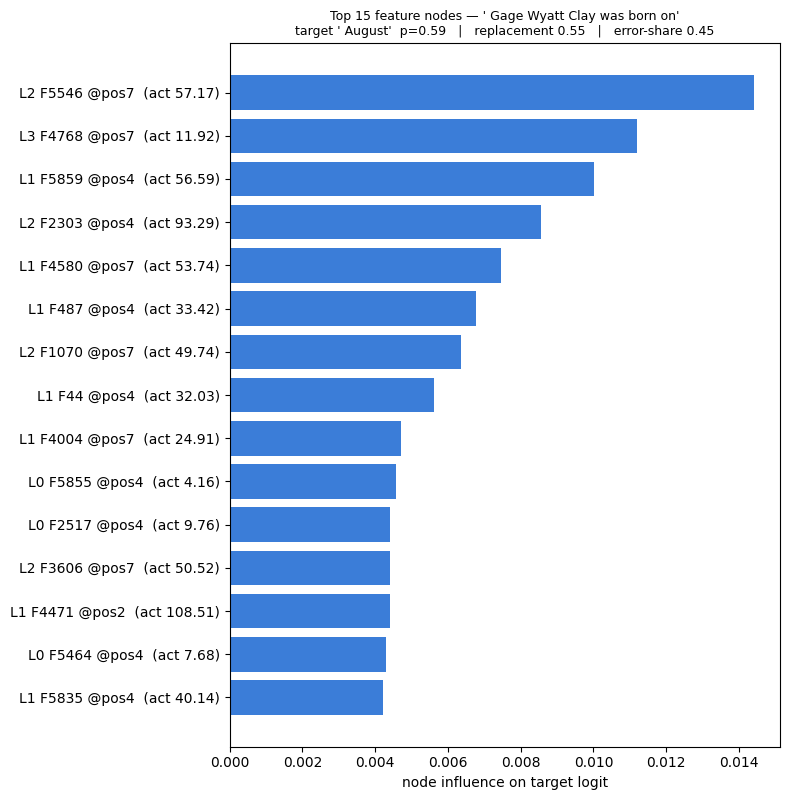

In [38]:
import matplotlib.pyplot as plt
import torch

from circuit_tracer.graph import compute_node_influence

TOP_K = 15

A = graph.adjacency_matrix.cpu()
n_logits   = len(graph.logit_targets)
n_features = len(graph.selected_features)

# logit_weights: weight only the logit nodes (last n_logits), as prune_graph does.
logit_weights = torch.zeros(A.shape[0])
logit_weights[-n_logits:] = graph.logit_probabilities.cpu()
node_influence = compute_node_influence(A, logit_weights)

feat_infl = node_influence[:n_features]
order = torch.argsort(feat_infl, descending=True)[:TOP_K]

labels, vals = [], []
for i in order.tolist():
    layer, pos, fidx = graph.active_features[graph.selected_features[i]].tolist()
    act = graph.activation_values[i].item()
    labels.append(f"L{layer} F{fidx} @pos{pos}  (act {act:.2f})")
    vals.append(feat_infl[i].item())

fig, ax = plt.subplots(figsize=(8, 0.42 * len(labels) + 1.8))
ax.barh(range(len(labels)), vals, color="#3b7dd8")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("node influence on target logit")
ax.set_title(
    f"Top {len(labels)} feature nodes — {report['prompt']!r}\n"
    f"target {report['top_logit_token']!r}  p={report['target_logit_prob']:.2f}   |   "
    f"replacement {report['replacement_score']:.2f}   |   "
    f"error-share {report['error_influence_share']:.2f}",
    fontsize=9,
)
plt.tight_layout()
plt.show()

## 7 · Launch the web viewer

Serves circuit-tracer's interactive viewer for the shared `explore/` folder (in-process). **Run this once** — it stays up across rebuilds. After re-running cells 3–5 for a new prompt, either open the printed `?slug=` link or pick the prompt from the **dropdown at the top of the viewer**. Call `server.stop()` to shut down.

In [ ]:
from clts.serve_ui import start_server

features_dir = storage_root() / "clt_features" / SCAN_NAME

# Reuse one server across rebuilds; stop a stale one first so the port isn't
# left held by an old graph folder (which would keep showing the old graph).
try:
    server.stop()
except NameError:
    pass
server = start_server(str(GRAPH_DIR), str(features_dir), SCAN_NAME, port=8032)

print(f"Viewer → http://localhost:8032/?slug={slug}")
print("That link loads THIS prompt's graph directly.")
print("For another prompt: re-run cells 3–5, then open its printed ?slug= link")
print("or switch via the dropdown at the top of the viewer (no restart needed).")
print("server.stop()  # to shut down")